In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [23]:
from sklearn.datasets import make_classification

In [24]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

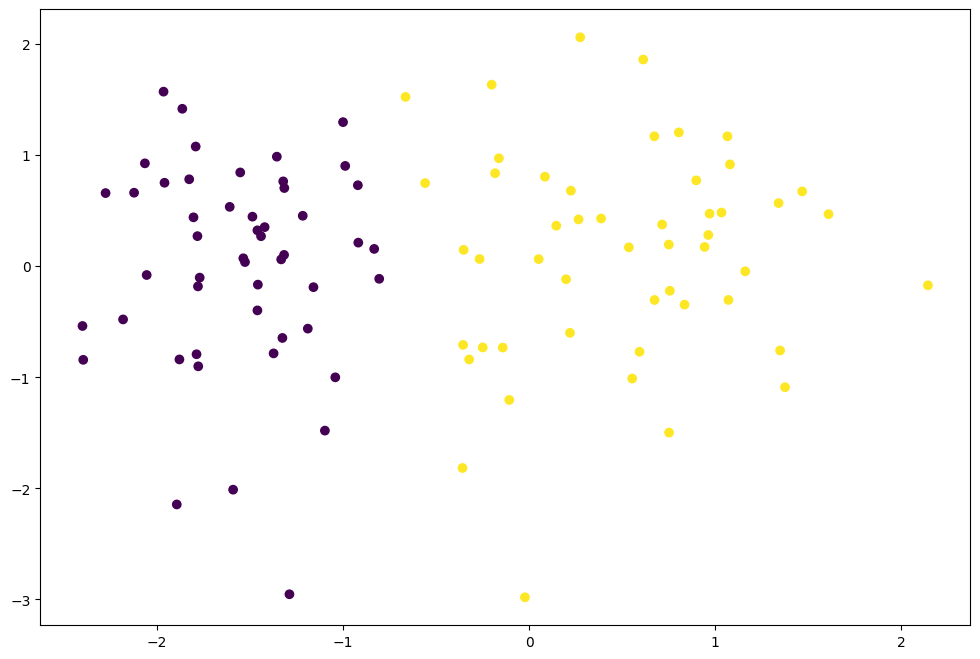

In [25]:
plt.figure(figsize = (12, 8))
plt.scatter(X[:,0], X[:,1], c = y)

In [26]:
def perceptron(X,y):
    X = np.insert(X,0,1 , axis = 1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr(y[j] - y_hat)*X[j]
    return weights[0], weights[1:]

In [27]:
def step(z):
    return 1 if z>0 else 0

In [28]:
from sklearn.linear_model import Perceptron

In [29]:
perceptron = Perceptron(fit_intercept=True,
    max_iter=1000,
    shuffle=False,
    random_state=42,
    tol=None)

In [30]:
perceptron.fit(X,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",None
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",False
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [31]:
intercept_,coef_ = perceptron.intercept_,perceptron.coef_

In [32]:
print(coef_)
print(intercept_)

[[2.75942958 0.17276711]]
[2.]


In [33]:
w1 = coef_[0][0]
w2 = coef_[0][1]
b = intercept_[0]

m = -(w1/w2)
c = -(b/w2)

print(m)
print(c)

-15.971961558160881
-11.576277694161936


In [34]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

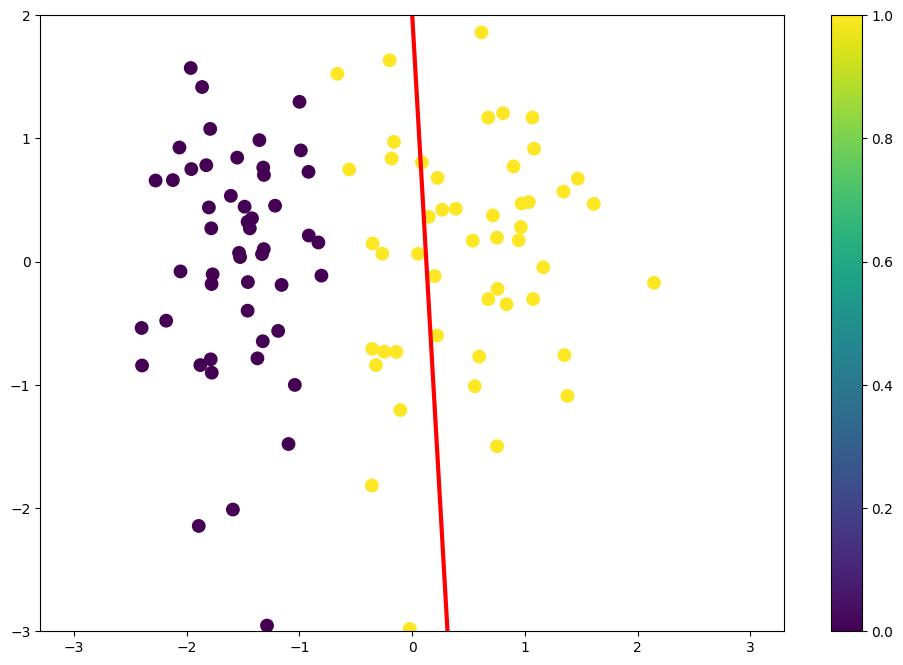

In [35]:
plt.figure(figsize=(12,8))
plt.plot(x_input,y_input,color = 'red', linewidth = 3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', s=80)
plt.ylim(-3,2)
plt.colorbar()